In [ ]:
!pip install datasets

from datasets import load_dataset

dataset = load_dataset("victor/real-or-fake-fake-jobposting-prediction")
df = dataset['train'].to_pandas()

print(df.shape)
print(df['fraudulent'].value_counts())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

fake_job_postings.csv:   0%|          | 0.00/50.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/17880 [00:00<?, ? examples/s]

(17880, 18)
fraudulent
0    17014
1      866
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Check nulls
print(df.isnull().sum())

# Key text columns
text_cols = ['title', 'company_profile', 'description', 'requirements', 'benefits']

# Combine all text into one column for NLP
df['text'] = df[text_cols].fillna('').agg(' '.join, axis=1)

# Drop rows where combined text is empty
df = df[df['text'].str.strip() != '']

print(df[['text', 'fraudulent']].head(3))

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64
                                                text  fraudulent
0  Marketing Intern We're Food52, and we've creat...           0
1  Customer Service - Cloud Video Production 90 S...           0
2  Commissioning Machinery Assistant (CMA) Valor ...           0


In [ ]:
# The dataset is ~95% real, ~5% fake — must handle this!

from sklearn.utils import resample

real = df[df['fraudulent'] == 0]
fake = df[df['fraudulent'] == 1]

# Oversample fake class to match real
fake_upsampled = resample(fake, replace=True, n_samples=len(real), random_state=42)
df_balanced = pd.concat([real, fake_upsampled]).sample(frac=1, random_state=42)

print(df_balanced['fraudulent'].value_counts())

fraudulent
1    17014
0    17014
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = df_balanced['text']
y = df_balanced['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# Evaluate
print(classification_report(y_test, model.predict(X_test_tfidf)))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3405
           1       0.98      1.00      0.99      3401

    accuracy                           0.99      6806
   macro avg       0.99      0.99      0.99      6806
weighted avg       0.99      0.99      0.99      6806



              precision    recall  f1-score   support

        Real       1.00      0.98      0.99      3405
        Fake       0.98      1.00      0.99      3401

    accuracy                           0.99      6806
   macro avg       0.99      0.99      0.99      6806
weighted avg       0.99      0.99      0.99      6806



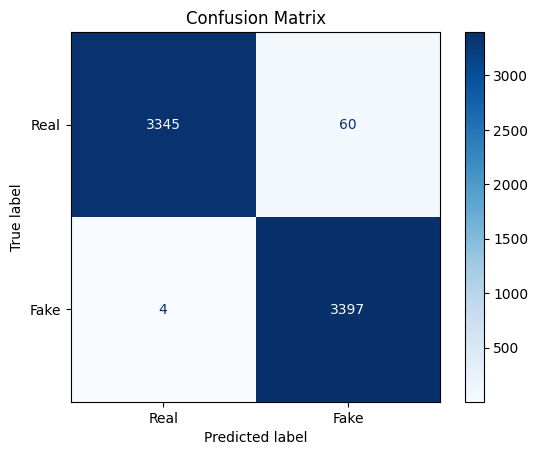

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# For Option A (Logistic Regression)
y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import joblib

joblib.dump(model, '/content/drive/MyDrive/fake_job_model.pkl')
joblib.dump(tfidf, '/content/drive/MyDrive/tfidf_vectorizer.pkl')

print("Model saved!")

Model saved!


In [ ]:
# Paste any job posting text here
new_post = ["We are looking for a Data Analyst with experience in Python and SQL. 3+ years required. Office based in Mumbai."]

# Predict
vec = tfidf.transform(new_post)
prediction = model.predict(vec)

if prediction[0] == 1:
    print("⚠️ FAKE job posting detected!")
else:
    print("✅ This looks like a REAL job posting")

✅ This looks like a REAL job posting


In [ ]:
# Paste any job posting text here
new_post = ["Work from home, earn $5000/week, no experience needed, unlimited income, apply now!!"]

# Predict
vec = tfidf.transform(new_post)
prediction = model.predict(vec)

if prediction[0] == 1:
    print("⚠️ FAKE job posting detected!")
else:
    print("✅ This looks like a REAL job posting")

⚠️ FAKE job posting detected!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Graphs saved to Drive!


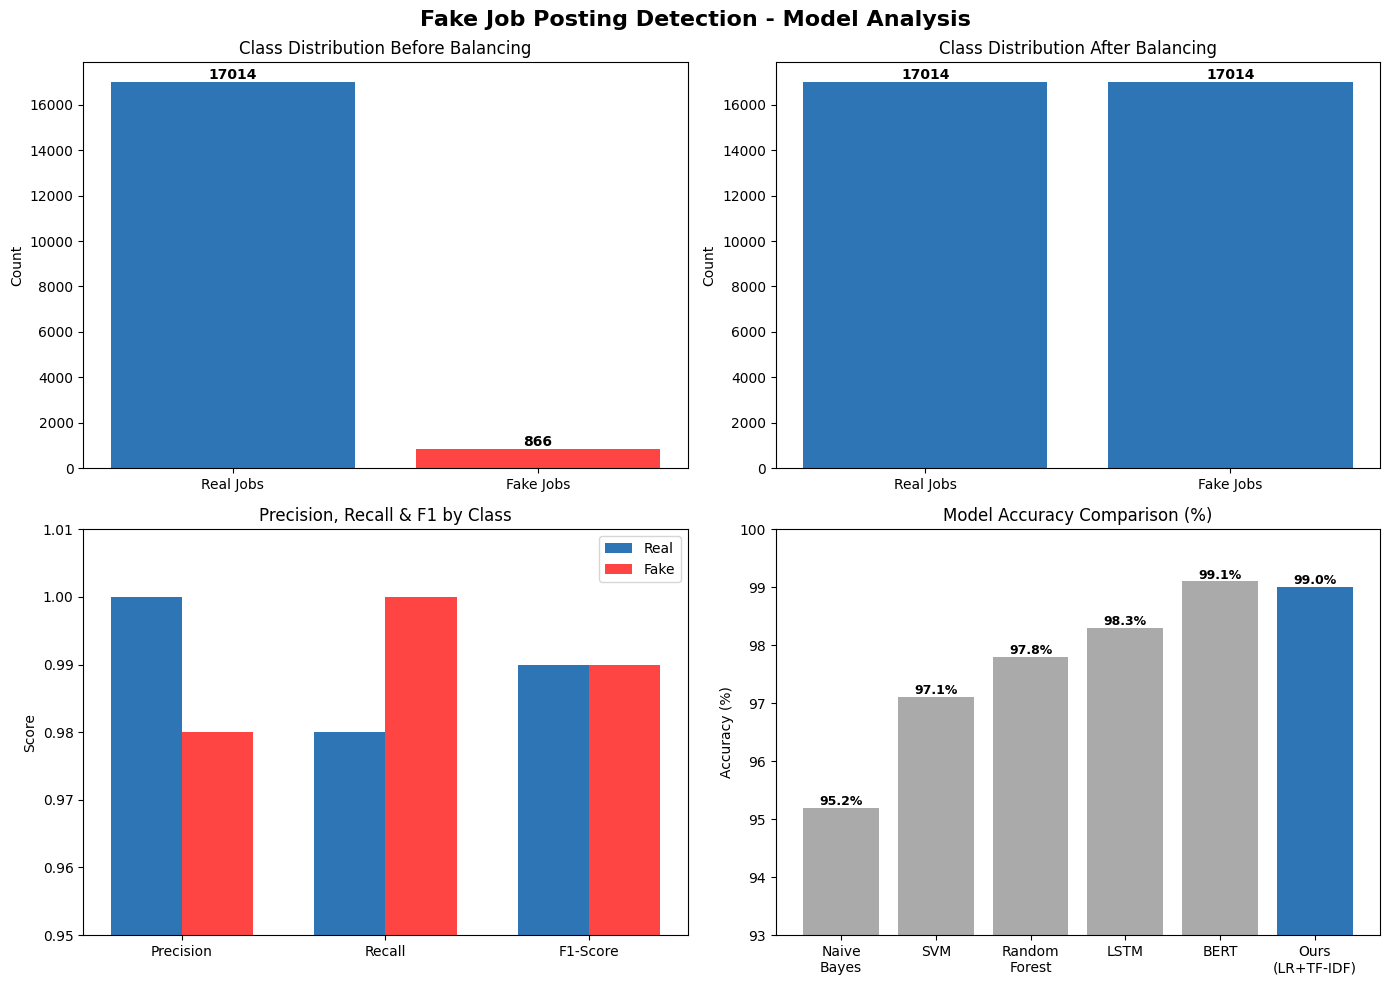

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fake Job Posting Detection - Model Analysis', fontsize=16, fontweight='bold')

# Graph 1 - Class Distribution Before Balancing
axes[0, 0].bar(['Real Jobs', 'Fake Jobs'], [17014, 866], color=['#2E75B6', '#FF4444'])
axes[0, 0].set_title('Class Distribution Before Balancing')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate([17014, 866]):
    axes[0, 0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Graph 2 - Class Distribution After Balancing
axes[0, 1].bar(['Real Jobs', 'Fake Jobs'], [17014, 17014], color=['#2E75B6', '#2E75B6'])
axes[0, 1].set_title('Class Distribution After Balancing')
axes[0, 1].set_ylabel('Count')
for i, v in enumerate([17014, 17014]):
    axes[0, 1].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Graph 3 - Precision Recall F1 Bar Chart
metrics = ['Precision', 'Recall', 'F1-Score']
real_scores = [1.00, 0.98, 0.99]
fake_scores = [0.98, 1.00, 0.99]
x = np.arange(len(metrics))
width = 0.35
axes[1, 0].bar(x - width/2, real_scores, width, label='Real', color='#2E75B6')
axes[1, 0].bar(x + width/2, fake_scores, width, label='Fake', color='#FF4444')
axes[1, 0].set_title('Precision, Recall & F1 by Class')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics)
axes[1, 0].set_ylim([0.95, 1.01])
axes[1, 0].legend()
axes[1, 0].set_ylabel('Score')

# Graph 4 - Model Comparison
models = ['Naive\nBayes', 'SVM', 'Random\nForest', 'LSTM', 'BERT', 'Ours\n(LR+TF-IDF)']
accuracies = [95.2, 97.1, 97.8, 98.3, 99.1, 99.0]
colors = ['#AAAAAA', '#AAAAAA', '#AAAAAA', '#AAAAAA', '#AAAAAA', '#2E75B6']
bars = axes[1, 1].bar(models, accuracies, color=colors)
axes[1, 1].set_title('Model Accuracy Comparison (%)')
axes[1, 1].set_ylim([93, 100])
axes[1, 1].set_ylabel('Accuracy (%)')
for bar, acc in zip(bars, accuracies):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f'{acc}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/model_analysis.png', dpi=150, bbox_inches='tight')
print("Graphs saved to Drive!")

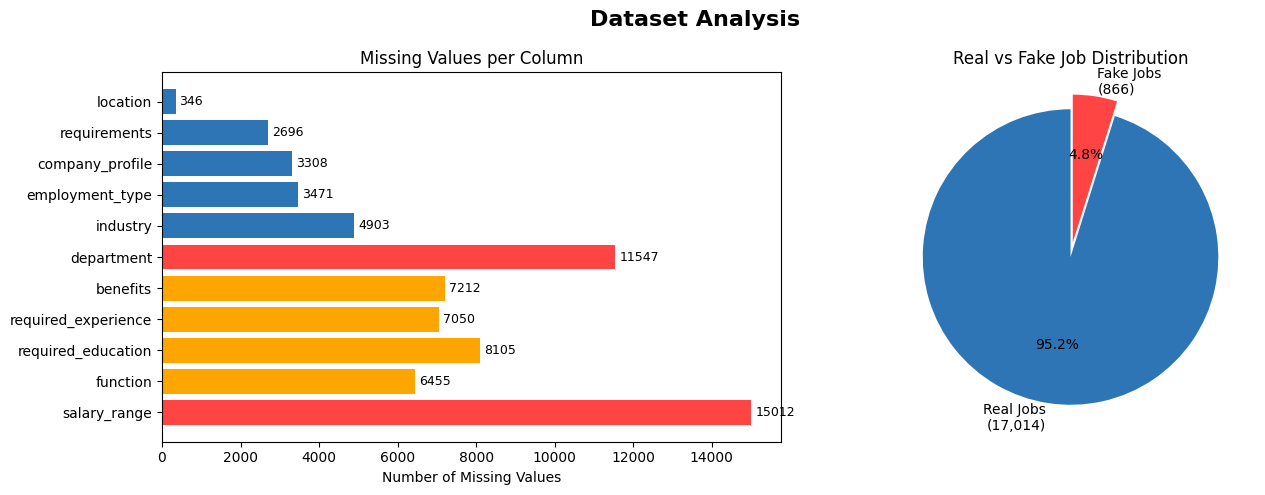

Saved!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Analysis', fontsize=16, fontweight='bold')

# Graph 1 - Missing Values per Column
missing = {
    'salary_range': 15012, 'function': 6455, 'required_education': 8105,
    'required_experience': 7050, 'benefits': 7212, 'department': 11547,
    'industry': 4903, 'employment_type': 3471, 'company_profile': 3308,
    'requirements': 2696, 'location': 346
}
cols = list(missing.keys())
vals = list(missing.values())
colors = ['#FF4444' if v > 10000 else '#FFA500' if v > 5000 else '#2E75B6' for v in vals]
bars = axes[0].barh(cols, vals, color=colors)
axes[0].set_title('Missing Values per Column')
axes[0].set_xlabel('Number of Missing Values')
for bar, val in zip(bars, vals):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9)

# Graph 2 - Pie Chart Real vs Fake
axes[1].pie(
    [17014, 866],
    labels=['Real Jobs\n(17,014)', 'Fake Jobs\n(866)'],
    colors=['#2E75B6', '#FF4444'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.1)
)
axes[1].set_title('Real vs Fake Job Distribution')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dataset_graphs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

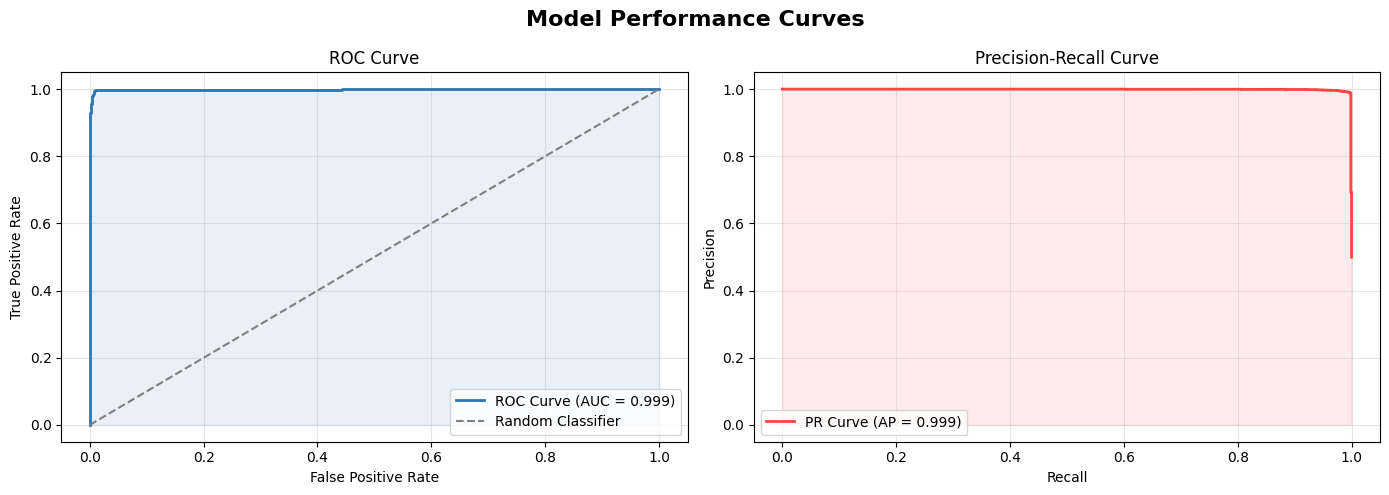

Saved!


In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Get probabilities
y_prob = model.predict_proba(X_test_tfidf)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance Curves', fontsize=16, fontweight='bold')

# Graph 3 - ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='#2E75B6', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#2E75B6')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Graph 4 - Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
axes[1].plot(recall, precision, color='#FF4444', lw=2, label=f'PR Curve (AP = {ap:.3f})')
axes[1].fill_between(recall, precision, alpha=0.1, color='#FF4444')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/performance_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")